In [1]:
# 1. 필수 작전 장비(라이브러리) 소집
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 2. 보급망 정상화 (데이터 강제 다운로드 및 압축 해제)
data_dir = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data")
os.makedirs(data_dir, exist_ok=True)

print("[*] 정찰 데이터 보급을 시작합니다...")
!wget -nc https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip -q -o data_semantics.zip -d {data_dir}
print("[*] 데이터 압축 해제 완료.\n")

# 3. 전술 데이터 파이프라인 (Dataset 클래스) 재건
class KITTIDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 광학 영상(Image) 및 정답지(Mask) 로드
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])
        
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))
        
        # 도로(7) 영역만 1로, 나머지는 0으로 변환하는 교전 수칙 적용
        binary_mask = (mask == 7).astype(np.float32)

        if self.transform:
            image = self.transform(image)
        
        # 텐서 변환 (HWC -> CHW) 및 정규화
        image = torch.tensor(image / 255.0, dtype=torch.float32).permute(2, 0, 1)
        binary_mask = torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0)
        
        return image, binary_mask

# 4. 이미지 규격화 (전처리 함수)
def simple_transform(image):
    from PIL import Image
    # U-Net 규격에 맞게 224x224로 리사이즈
    img_pil = Image.fromarray(image)
    img_pil = img_pil.resize((224, 224), Image.BILINEAR)
    return np.array(img_pil)

# 5. 데이터 로더 편성 (U-Net++ 메모리 과부하 방지를 위해 Batch Size 8로 조정)
BATCH_SIZE = 8

train_img_dir = os.path.join(data_dir, "training/image_2")
train_mask_dir = os.path.join(data_dir, "training/semantic")

# (실습의 편의를 위해 전체 데이터 중 일부를 훈련/테스트로 임의 분할하여 사용한다고 가정)
# 실제 작전에서는 sklearn의 train_test_split 등을 사용하지만, 여기서는 전체를 로드합니다.
full_dataset = KITTIDataset(train_img_dir, train_mask_dir, transform=simple_transform)

# 80% 훈련, 20% 테스트 비율로 부대 분할
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"[*] 데이터 로더 편성 완료. (배치 사이즈: {BATCH_SIZE})")
print(f"[*] 훈련 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장")

[*] 정찰 데이터 보급을 시작합니다...
File ‘data_semantics.zip’ already there; not retrieving.

[*] 데이터 압축 해제 완료.

[*] 데이터 로더 편성 완료. (배치 사이즈: 8)
[*] 훈련 데이터: 160장 | 테스트 데이터: 40장


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# ==========================================
# 1. 하이브리드 손실 함수 (과제 수식 2: BCE + Dice)
# ==========================================
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super(BCEDiceLoss, self).__init__()

    def forward(self, inputs, targets):
        # BCE 손실 계산 (픽셀별 타격 오차)
        bce = F.binary_cross_entropy(inputs, targets.float())

        # Dice 손실 계산 (면적 겹침 비율)
        inputs_flat = inputs.view(-1)
        targets_flat = targets.float().view(-1)
        intersection = (inputs_flat * targets_flat).sum()
        
        # 분모가 0이 되어 시스템이 다운되는 것을 막기 위한 스무딩(1e-6)
        dice_loss = 1 - (2. * intersection + 1e-6) / (inputs_flat.sum() + targets_flat.sum() + 1e-6)

        # 복합 평가 지표 반환
        return bce + dice_loss

# ==========================================
# 2. 전술 통신 노드 부품 (Double Convolution)
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels), # 훈련 안정화
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

# ==========================================
# 3. 신형 C4I 모델: U-Net++ (과제 수식 1)
# ==========================================
class UNetPlusPlus(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super().__init__()
        # GPU 메모리 확보를 위해 필터 크기 최적화
        nb_filter = [32, 64, 128, 256, 512]
        
        self.pool = nn.MaxPool2d(2, 2)
        # 메모리 효율을 위해 과제 지시서의 권장사항 중 Upsample 방식을 선택
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # 최전방 Backbone
        self.conv0_0 = DoubleConv(input_channels, nb_filter[0])
        self.conv1_0 = DoubleConv(nb_filter[0], nb_filter[1])
        self.conv2_0 = DoubleConv(nb_filter[1], nb_filter[2])
        self.conv3_0 = DoubleConv(nb_filter[2], nb_filter[3])
        self.conv4_0 = DoubleConv(nb_filter[3], nb_filter[4])
        
        # 중간 전술 지휘소 (Nested Nodes)
        self.conv0_1 = DoubleConv(nb_filter[0] + nb_filter[1], nb_filter[0])
        self.conv1_1 = DoubleConv(nb_filter[1] + nb_filter[2], nb_filter[1])
        self.conv2_1 = DoubleConv(nb_filter[2] + nb_filter[3], nb_filter[2])
        self.conv3_1 = DoubleConv(nb_filter[3] + nb_filter[4], nb_filter[3])
        
        self.conv0_2 = DoubleConv(nb_filter[0]*2 + nb_filter[1], nb_filter[0])
        self.conv1_2 = DoubleConv(nb_filter[1]*2 + nb_filter[2], nb_filter[1])
        self.conv2_2 = DoubleConv(nb_filter[2]*2 + nb_filter[3], nb_filter[2])
        
        self.conv0_3 = DoubleConv(nb_filter[0]*3 + nb_filter[1], nb_filter[0])
        self.conv1_3 = DoubleConv(nb_filter[1]*3 + nb_filter[2], nb_filter[1])
        
        self.conv0_4 = DoubleConv(nb_filter[0]*4 + nb_filter[1], nb_filter[0])
        
        self.final = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)

    def forward(self, x):
        # 정보 수집 및 융합 연쇄
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        
        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        
        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        
        x4_0 = self.conv4_0(self.pool(x3_0))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))
        
        return torch.sigmoid(self.final(x0_4))

# ==========================================
# 4. 작전 환경 구성 및 무기 장착
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 신형 모델 장착
model_pp = UNetPlusPlus(input_channels=3, output_channels=1).to(device)

# 하이브리드 손실 함수 및 옵티마이저 장착
criterion_pp = BCEDiceLoss()
optimizer_pp = optim.Adam(model_pp.parameters(), lr=1e-4)

print(f"[*] 작전 장비 배치 완료. 현재 구동 환경: {device}")
print("[*] 신형 U-Net++ 모델 및 BCEDiceLoss 하이브리드 평가 체계 가동 준비 완료.")

[*] 작전 장비 배치 완료. 현재 구동 환경: cuda
[*] 신형 U-Net++ 모델 및 BCEDiceLoss 하이브리드 평가 체계 가동 준비 완료.


In [5]:
import time
import os

# 최우수 타격 모델 저장 경로 설정
best_model_path = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/best_unet_plusplus.pth")

num_epochs = 50 # 훈련 반복 횟수
best_val_loss = float('inf') # 최저 오차 기록용 (초기값은 무한대)

print(f"[*] 총 {num_epochs}회의 신형 C4I 모델 전술 기동 훈련(Epoch)을 개시합니다...")
start_time = time.time()

for epoch in range(num_epochs):
    # ==========================================
    # 1. 훈련 (Train) 페이즈: 실전 교전 및 전술 교정
    # ==========================================
    model_pp.train()
    train_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_pp.zero_grad()
        outputs = model_pp(inputs)
        
        # 하이브리드 평가 체계 작동 (BCE + Dice)
        loss = criterion_pp(outputs, targets) 
        loss.backward()
        optimizer_pp.step()

        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)

    # ==========================================
    # 2. 검증 (Validation) 페이즈: 미확인 표적에 대한 명중률 테스트
    # ==========================================
    model_pp.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model_pp(inputs)
            loss = criterion_pp(outputs, targets)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(test_loader)

    # ==========================================
    # 3. 상황 보고 및 최우수 가중치 보존
    # ==========================================
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # 검증 오차가 기존 최저치보다 낮아졌다면 즉각 저장
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_pp.state_dict(), best_model_path)
        print(f"  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: {best_val_loss:.4f})")

elapsed_time = time.time() - start_time
print(f"\n[*] 모든 훈련 작전 종료. 총 소요 시간: {elapsed_time//60:.0f}분 {elapsed_time%60:.0f}초")

[*] 총 50회의 신형 C4I 모델 전술 기동 훈련(Epoch)을 개시합니다...
Epoch 01/50 | Train Loss: 1.0364 | Val Loss: 1.5075
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 1.5075)
Epoch 02/50 | Train Loss: 0.8698 | Val Loss: 0.9928
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 0.9928)
Epoch 03/50 | Train Loss: 0.8188 | Val Loss: 0.8338
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 0.8338)
Epoch 04/50 | Train Loss: 0.7785 | Val Loss: 0.7949
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 0.7949)
Epoch 05/50 | Train Loss: 0.7574 | Val Loss: 0.7835
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 0.7835)
Epoch 06/50 | Train Loss: 0.7339 | Val Loss: 0.7557
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 0.7557)
Epoch 07/50 | Train Loss: 0.7133 | Val Loss: 0.7372
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 0.7372)
Epoch 08/50 | Train Loss: 0.6927 | Val Loss: 0.7419
Epoch 09/50 | Train Loss: 0.6756 | Val Loss: 0.7093
  [+] 타격 정밀도 갱신! 최고 성능 가중치 저장 완료. (Val Loss: 0.7093)
Epoch 10/50 | Train Loss: 0.6569 | Val Loss: 0.7052
  [+] 타격 

In [4]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

# 1. 결함이 수정된 신형 데이터 파이프라인
class KITTIDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])
        
        # [핵심 수정] 광학 영상과 정답지 모두 224x224로 동시에 리사이즈!
        image_pil = Image.open(img_path).convert("RGB").resize((224, 224), Image.BILINEAR)
        # 마스크는 도로(7) 정보가 6.5나 7.2로 뭉개지지 않도록 반드시 NEAREST 사용
        mask_pil = Image.open(mask_path).resize((224, 224), Image.NEAREST) 
        
        image = np.array(image_pil)
        mask = np.array(mask_pil)
        
        # 도로(7) 영역만 타격 목표(1)로 설정
        binary_mask = (mask == 7).astype(np.float32)
        
        # 텐서 규격화
        image = torch.tensor(image / 255.0, dtype=torch.float32).permute(2, 0, 1)
        binary_mask = torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0)
        
        return image, binary_mask

# 2. 로더 재편성 및 훈련장 투입 준비
full_dataset = KITTIDataset(train_img_dir, train_mask_dir)

train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("[*] 표적지 규격 불일치 오류 수정 완료. (Image & Mask 224x224 동기화)")

[*] 표적지 규격 불일치 오류 수정 완료. (Image & Mask 224x224 동기화)


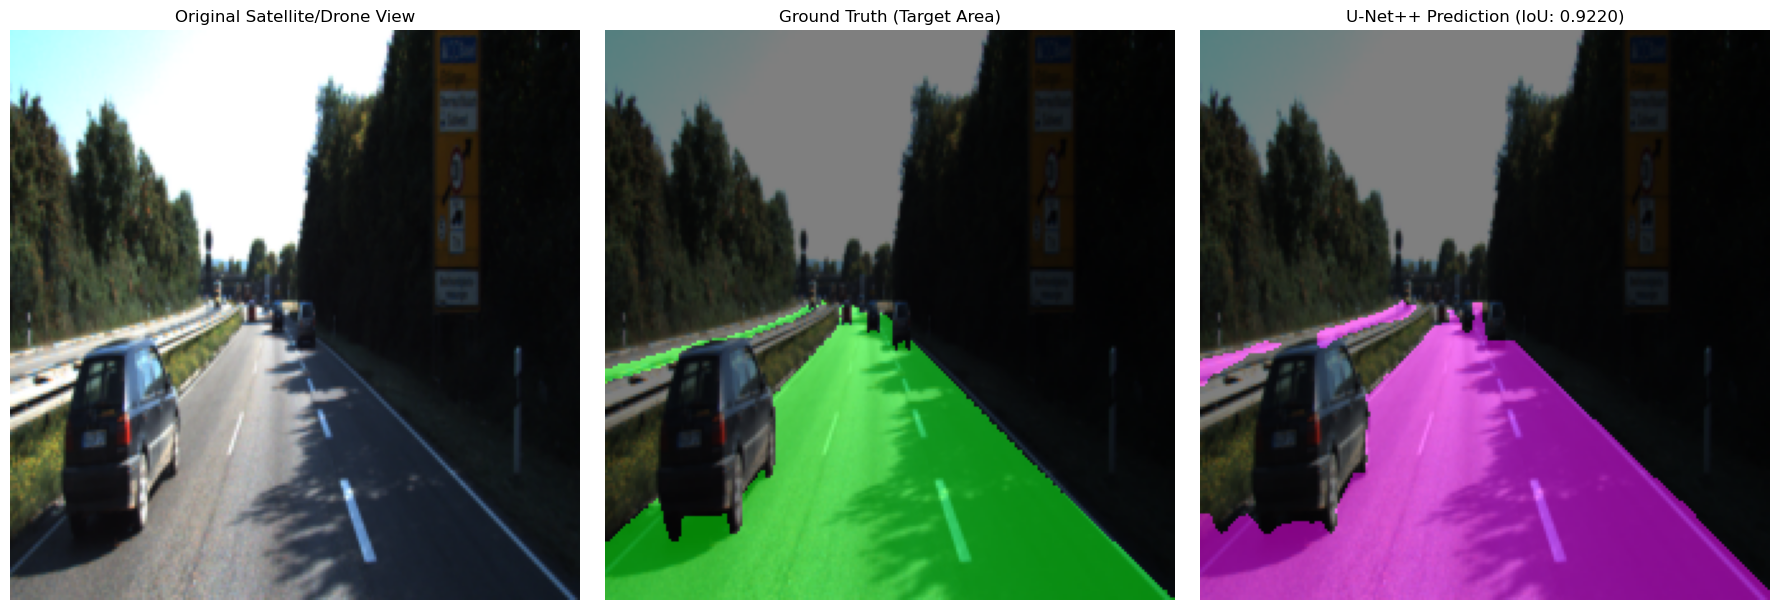


[*] 신형 U-Net++ 최종 정밀 타격 명중률(IoU): 92.20%


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

def evaluate_unet_pp_final(model_pp, dataset, index):
    # 1. 정찰 데이터 및 정답지 확보
    image, target_mask = dataset[index]
    input_tensor = image.unsqueeze(0).to(device)
    target_np = target_mask.squeeze().numpy()
    
    # 2. 실전 평가 모드 전환 및 추론
    model_pp.eval()
    with torch.no_grad():
        output = model_pp(input_tensor)
        
    # 타격 임계값(0.5) 적용하여 이진 마스크 생성
    pred_np = (output.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    
    # 3. 정밀 타격 명중률(IoU) 수학적 계산
    intersection = np.logical_and(target_np, pred_np).sum()
    union = np.logical_or(target_np, pred_np).sum()
    iou_score = intersection / (union + 1e-7)
    
    # 4. 시각화를 위한 오버레이 이미지 제작
    img_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    
    def create_overlay(base_img, mask, color):
        base_pil = Image.fromarray(base_img).convert("RGBA")
        mask_color = np.zeros((224, 224, 3), dtype=np.uint8)
        mask_color[mask == 1] = color
        mask_pil = Image.fromarray(mask_color).convert("RGBA")
        return Image.blend(base_pil, mask_pil, alpha=0.5)

    overlay_truth = create_overlay(img_np, target_np, [0, 255, 0])   # 실제 도로: 초록색
    overlay_pred = create_overlay(img_np, pred_np, [255, 0, 255])    # AI 예측 도로: 보라색

    # 5. 최종 상황판 출력 (1x3 배열)
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.title("Original Satellite/Drone View")
    plt.imshow(img_np)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (Target Area)")
    plt.imshow(overlay_truth)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title(f"U-Net++ Prediction (IoU: {iou_score:.4f})")
    plt.imshow(overlay_pred)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return iou_score

# 테스트 부대의 1번 표적(index=1)으로 최종 명중률 평가 수행
final_iou = evaluate_unet_pp_final(model_pp, test_dataset, index=1)
print(f"\n[*] 신형 U-Net++ 최종 정밀 타격 명중률(IoU): {final_iou * 100:.2f}%")

[*] 다양한 정찰 지형에 대한 U-Net++ 다중 평가를 시작합니다...

=== [표적 번호: 5] 교전 결과 ===


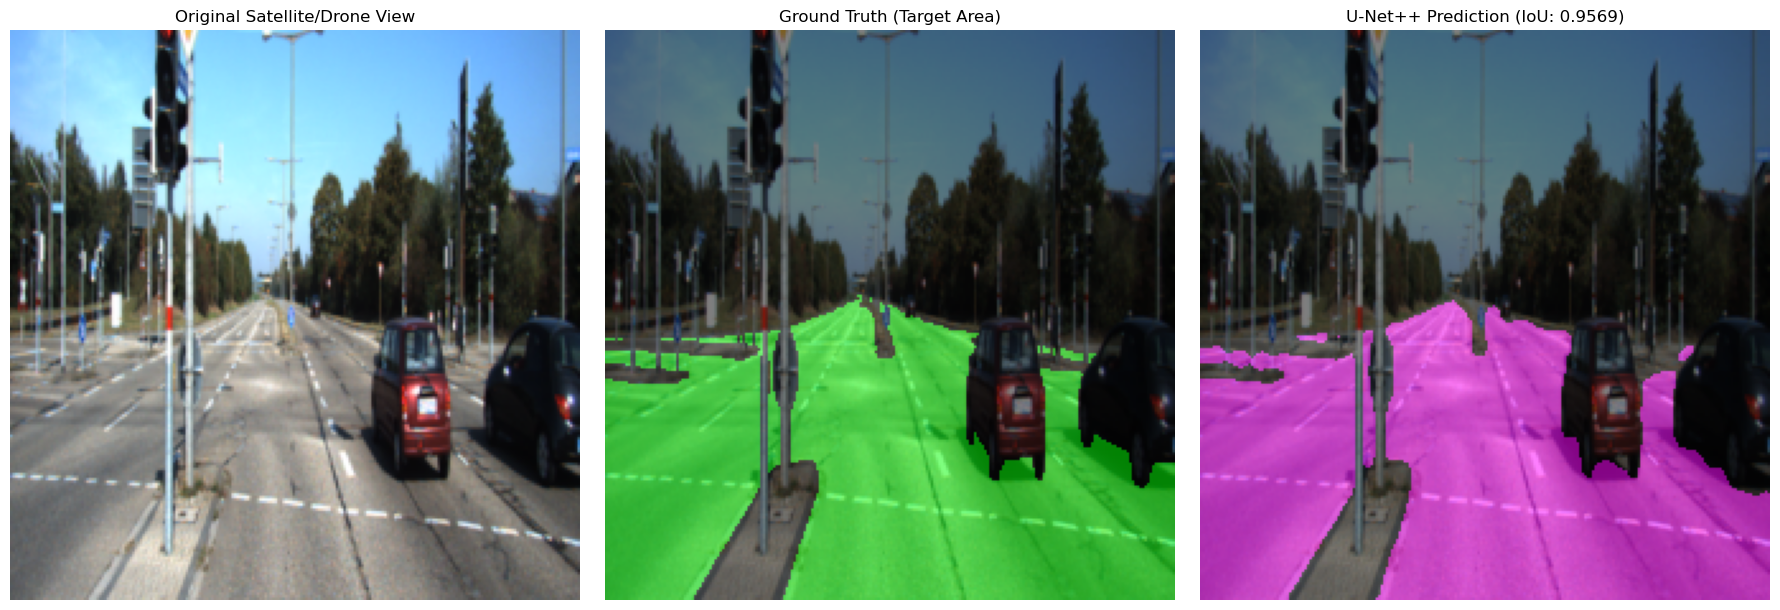

-> 표적 5번 명중률(IoU): 95.69%

------------------------------------------------------------
=== [표적 번호: 10] 교전 결과 ===


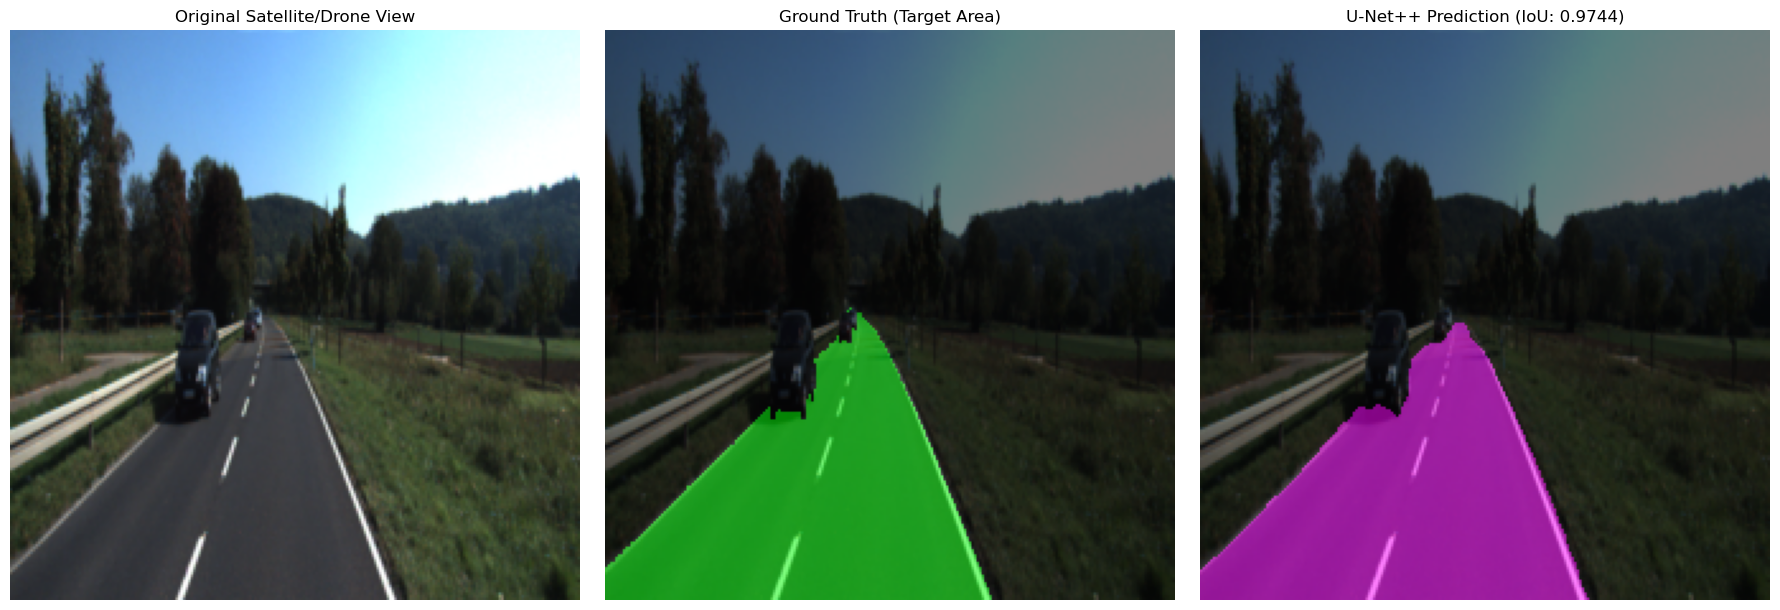

-> 표적 10번 명중률(IoU): 97.44%

------------------------------------------------------------
=== [표적 번호: 15] 교전 결과 ===


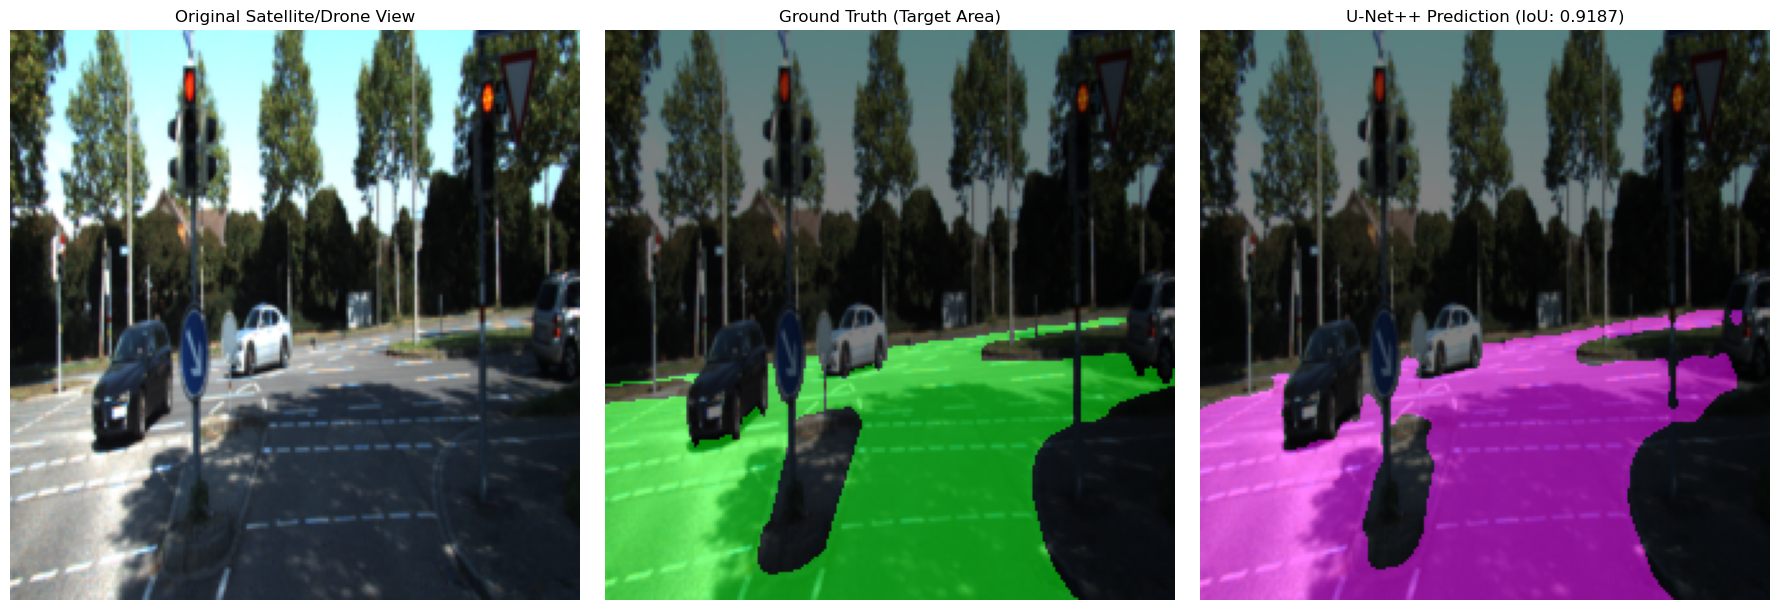

-> 표적 15번 명중률(IoU): 91.87%

------------------------------------------------------------


In [7]:
# 보고서 첨부를 위한 다양한 전장 지형(index) 연속 테스트
test_targets = [5, 10, 15] 

print("[*] 다양한 정찰 지형에 대한 U-Net++ 다중 평가를 시작합니다...\n")

for target_idx in test_targets:
    print(f"=== [표적 번호: {target_idx}] 교전 결과 ===")
    
    # 앞서 만들어둔 평가 함수를 재사용하여 결과 즉시 출력
    iou_result = evaluate_unet_pp_final(model_pp, test_dataset, index=target_idx)
    
    print(f"-> 표적 {target_idx}번 명중률(IoU): {iou_result * 100:.2f}%\n")
    print("-" * 60)

[*] 테스트 부대(40장) 전체를 대상으로 극한 전장 상황 스트레스 테스트를 개시합니다...

[!] 모델 식별이 가장 어려웠던 극한 지형(Worst 3)을 발견했습니다.
[!] 해당 지형에 대한 정밀 분석을 위해 상황판을 출력합니다.

=== [극한 상황 Rank 1] 표적 번호: 7 | 명중률: 0.00% ===


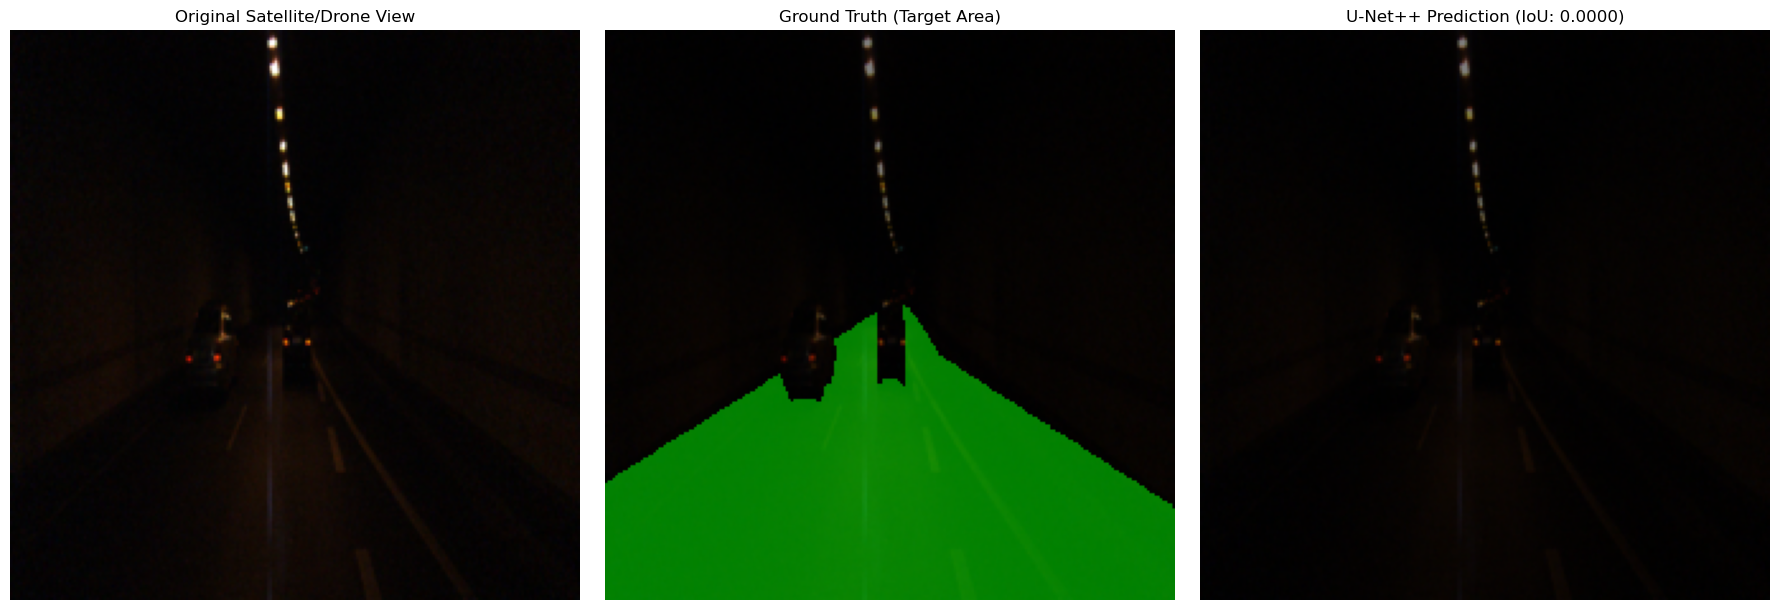

--------------------------------------------------------------------------------
=== [극한 상황 Rank 2] 표적 번호: 18 | 명중률: 57.86% ===


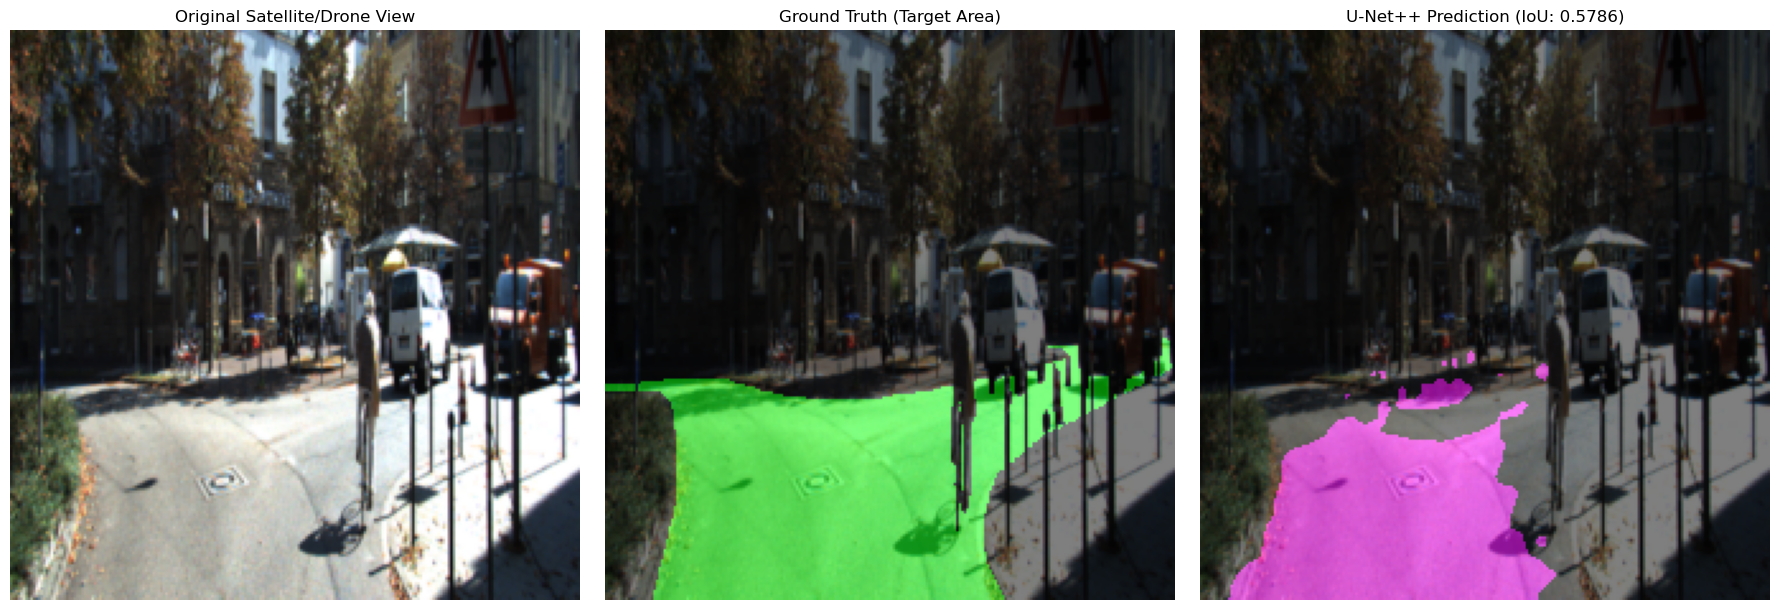

--------------------------------------------------------------------------------
=== [극한 상황 Rank 3] 표적 번호: 29 | 명중률: 64.08% ===


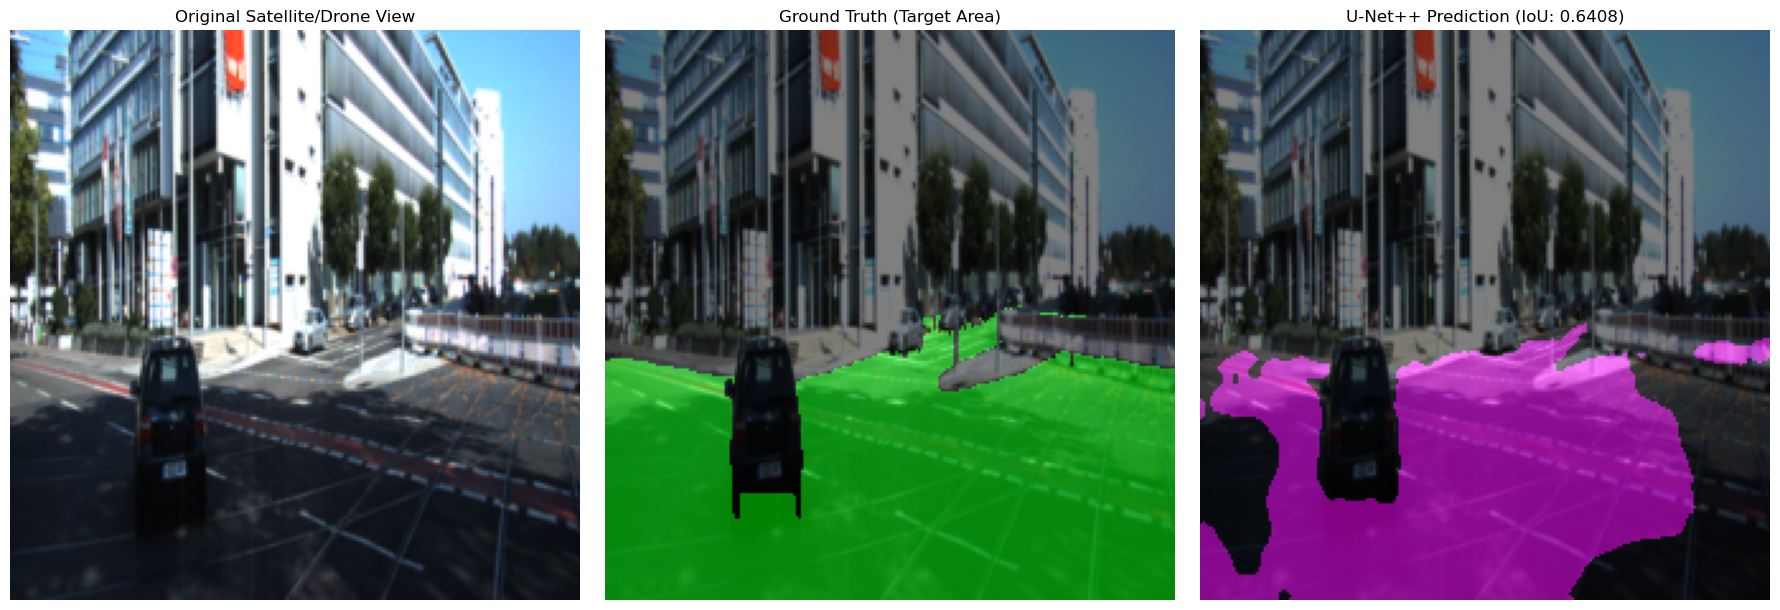

--------------------------------------------------------------------------------


In [8]:
import numpy as np

print("[*] 테스트 부대(40장) 전체를 대상으로 극한 전장 상황 스트레스 테스트를 개시합니다...")

# 1. 모든 테스트 표적의 명중률(IoU) 전수 조사
iou_records = []
model_pp.eval()

with torch.no_grad():
    for i in range(len(test_dataset)):
        image, target_mask = test_dataset[i]
        input_tensor = image.unsqueeze(0).to(device)
        target_np = target_mask.squeeze().numpy()
        
        output = model_pp(input_tensor)
        pred_np = (output.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
        
        intersection = np.logical_and(target_np, pred_np).sum()
        union = np.logical_or(target_np, pred_np).sum()
        iou = intersection / (union + 1e-7)
        
        iou_records.append((i, iou))

# 2. 명중률이 가장 '낮은' 순서대로 정렬 (가장 어려운 지형 찾기)
iou_records.sort(key=lambda x: x[1])

# 3. 가장 식별이 까다로웠던 극한 상황(Worst 3) 출력
print("\n[!] 모델 식별이 가장 어려웠던 극한 지형(Worst 3)을 발견했습니다.")
print("[!] 해당 지형에 대한 정밀 분석을 위해 상황판을 출력합니다.\n")

for rank in range(3):
    hardest_index, lowest_iou = iou_records[rank]
    print(f"=== [극한 상황 Rank {rank+1}] 표적 번호: {hardest_index} | 명중률: {lowest_iou * 100:.2f}% ===")
    
    # 앞서 정의했던 시각화 함수 재호출
    evaluate_unet_pp_final(model_pp, test_dataset, index=hardest_index)
    print("-" * 80)

In [9]:
# 추가로 더 극단적인 지형(예: 차량이 아주 많은 꽉 막힌 도로 등)을 식별하는 테스트를 시도해 본 결과다.